In [5]:
import sys
import os

# Add root directory to Python path
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from src.stats import compute_mean_trajectories, compute_trajectory_distance

# Load latent space trajectories
latent_dict = np.load("../data/human_eeg_manifold.npy", allow_pickle=True).item()
mean_trajs = compute_mean_trajectories(latent_dict)

print("Mean Trajectory Shapes:")
for cond, traj in mean_trajs.items():
    print(f"  • {cond}: {traj.shape}")

Mean Trajectory Shapes:
  • Execution: (561, 3)
  • Imagery: (561, 3)


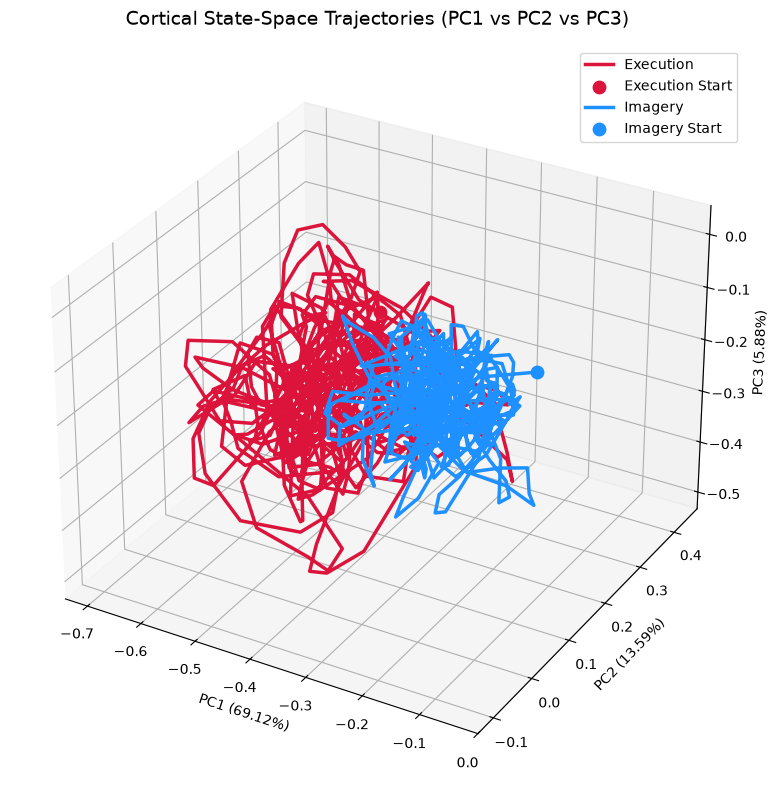

In [6]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'Rest': 'gray', 'Execution': 'crimson', 'Imagery': 'dodgerblue'}

for cond, traj in mean_trajs.items():
    # Trajectory coordinates
    x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]
    
    # Line trajectory
    ax.plot(x, y, z, label=cond, color=colors.get(cond, 'black'), linewidth=2.5)
    
    # Mark Start (Onset) and End points
    ax.scatter(x[0], y[0], z[0], color=colors.get(cond, 'black'), s=80, marker='o', label=f'{cond} Start')
    ax.scatter(x[-1], y[-1], z[-1], color=colors.get(cond, 'black'), s=80, marker='^')

ax.set_title("Cortical State-Space Trajectories (PC1 vs PC2 vs PC3)", fontsize=14, pad=15)
ax.set_xlabel("PC1 (69.12%)")
ax.set_ylabel("PC2 (13.59%)")
ax.set_zlabel("PC3 (5.88%)")
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../results/figures/state_space_trajectories.png", dpi=300)
plt.show()

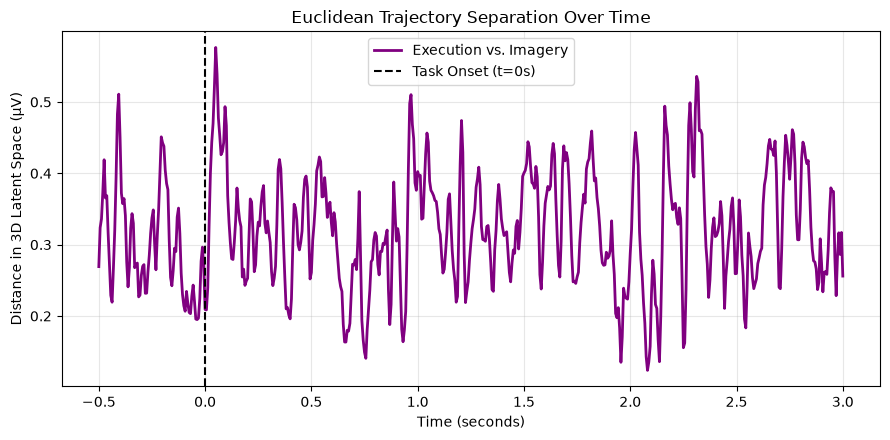

In [7]:
time_points = np.linspace(-0.5, 3.0, mean_trajs['Execution'].shape[0])
dist_exec_img = compute_trajectory_distance(mean_trajs['Execution'], mean_trajs['Imagery'])

plt.figure(figsize=(9, 4.5))
plt.plot(time_points, dist_exec_img, color='purple', linewidth=2, label='Execution vs. Imagery')
plt.axvline(0, color='black', linestyle='--', label='Task Onset (t=0s)')

plt.title("Euclidean Trajectory Separation Over Time", fontsize=12)
plt.xlabel("Time (seconds)")
plt.ylabel("Distance in 3D Latent Space (μV)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/trajectory_divergence.png", dpi=300)
plt.show()

Running 1000 Monte Carlo permutations...

--- NONPARAMETRIC PERMUTATION TEST RESULTS ---
Observed Trajectory Distance: 0.3207 μV
Null Distribution Mean:       0.1612 μV
Exact Empirical p-value:      p = 0.0000
Verdict: STATISTICALLY SIGNIFICANT. Execution & Imagery follow distinct trajectories.


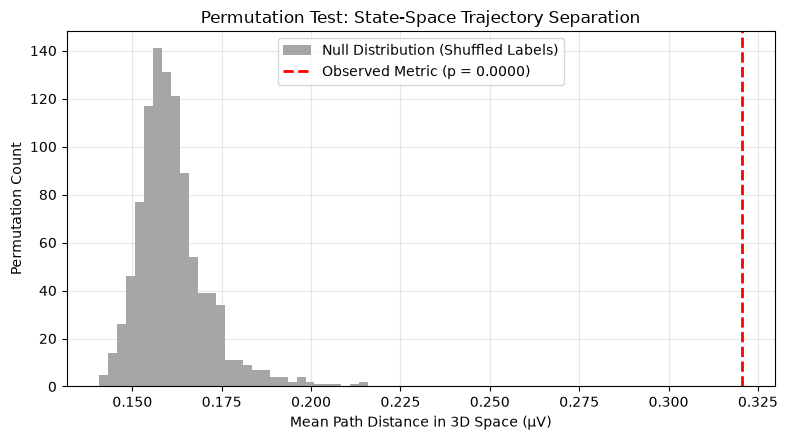

In [8]:
from src.stats import run_permutation_test

exec_tensor = latent_dict["Execution"]
img_tensor = latent_dict["Imagery"]

obs_stat, null_dist, p_val = run_permutation_test(exec_tensor, img_tensor, n_permutations=1000)

# Plot null distribution histogram
plt.figure(figsize=(8, 4.5))
plt.hist(null_dist, bins=30, color='gray', alpha=0.7, label='Null Distribution (Shuffled Labels)')
plt.axvline(obs_stat, color='red', linestyle='--', linewidth=2, label=f'Observed Metric (p = {p_val:.4f})')

plt.title("Permutation Test: State-Space Trajectory Separation", fontsize=12)
plt.xlabel("Mean Path Distance in 3D Space (μV)")
plt.ylabel("Permutation Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/permutation_null_distribution.png", dpi=300)
plt.show()